In [66]:
import pandas as pd
from shapely.geometry import Point
import requests
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import geopandas as gpd
import matplotlib.pyplot as plt
import glob
import os

In [67]:
lsoa_to_station = pd.read_csv("../data/shape/lsoa_station_map.csv")
stations_df = pd.read_csv("../services/police_stations.csv")

base_path = "../data/LB_shp"
shapefiles = glob.glob(os.path.join(base_path, "**/*.shp"), recursive=True)
lsoa_gdfs = [gpd.read_file(shp) for shp in shapefiles]
lsoa_london = gpd.GeoDataFrame(
    pd.concat(lsoa_gdfs, ignore_index=True),
    crs=lsoa_gdfs[0].crs
)

In [68]:
lsoa_map = lsoa_london.merge(
    lsoa_to_station,
    on="LSOA21CD",
    how="left"
)

In [69]:

stations_df = gpd.GeoDataFrame(
    stations_df,
    geometry=gpd.points_from_xy(stations_df["longitude"], stations_df["latitude"]),
    crs="EPSG:27700"
)

stations_gdf = gpd.GeoDataFrame(
    stations_df,
    geometry=gpd.points_from_xy(
        stations_df["longitude"],
        stations_df["latitude"]
    ),
    crs="EPSG:4326"
)

stations_gdf = stations_gdf.to_crs(lsoa_map.crs)

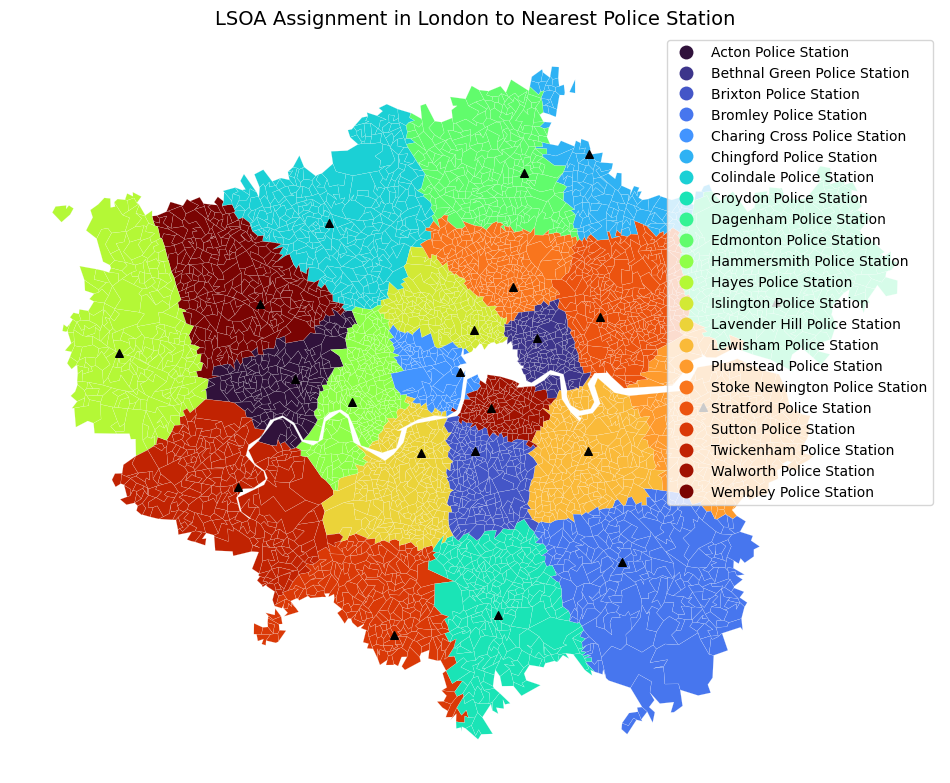

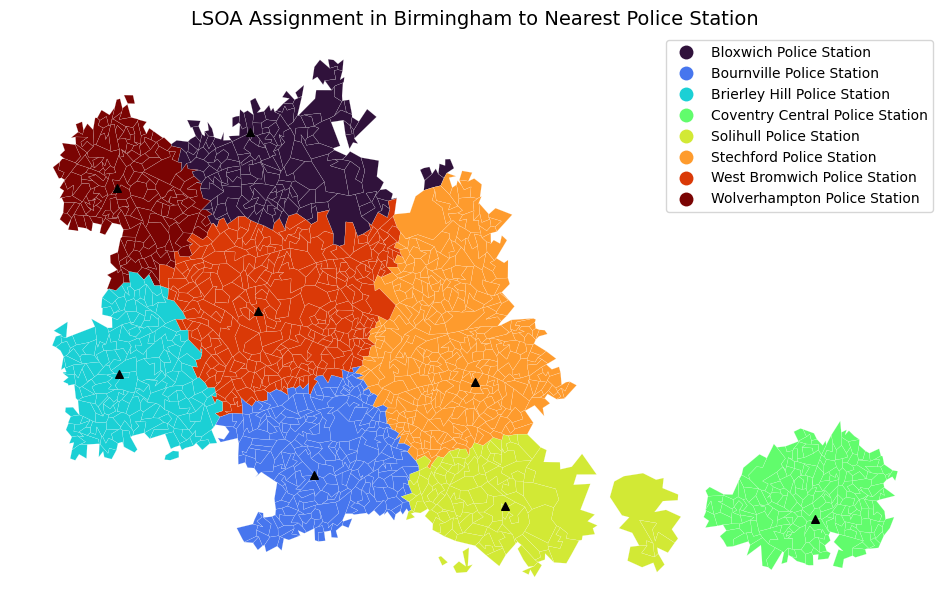

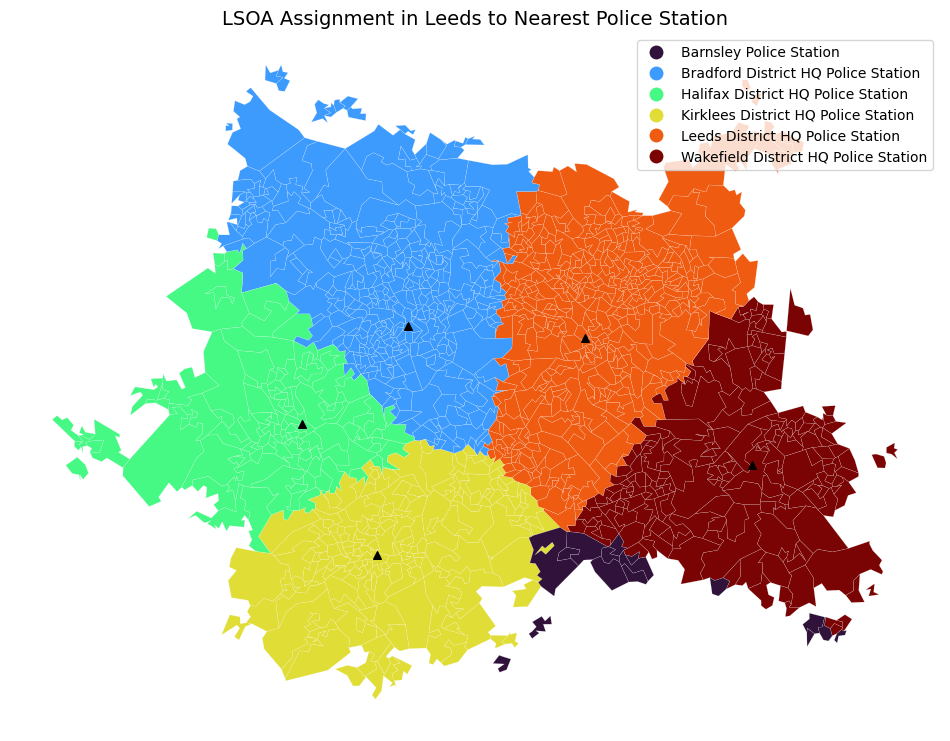

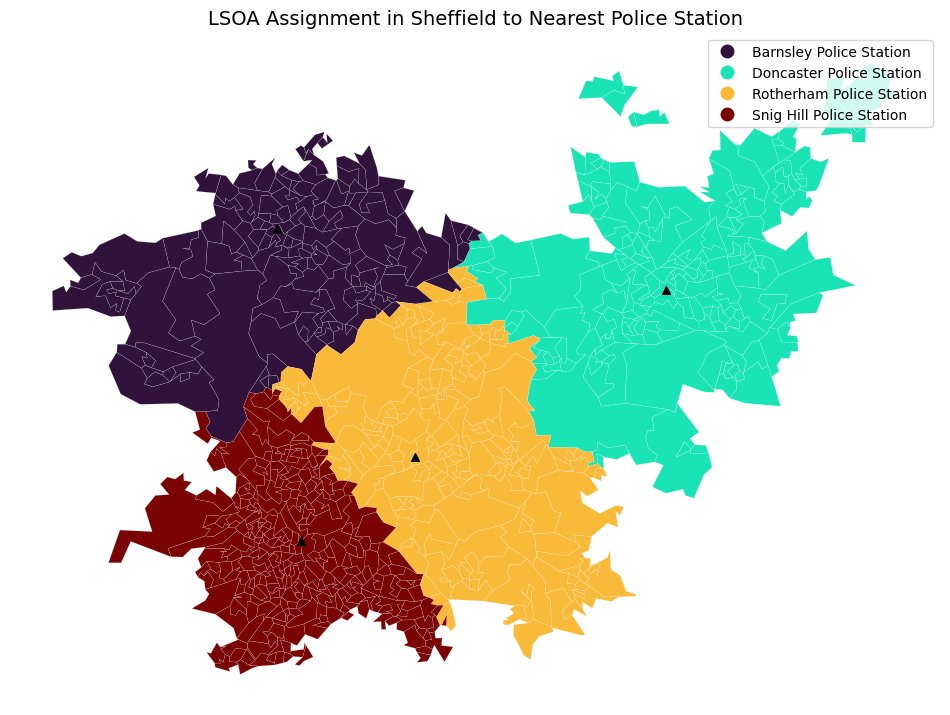

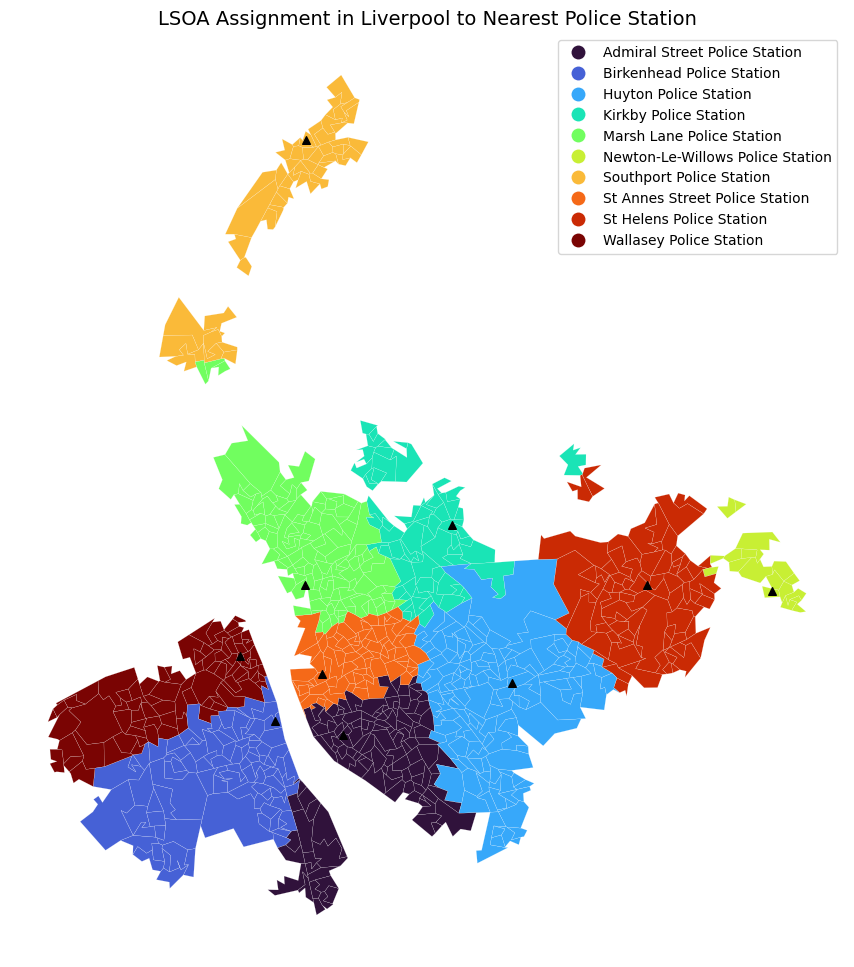

In [86]:
city_to_police_force = {
    "London": "metropolitan",
    "Birmingham": "west-midlands",
    "Leeds": "west-yorkshire",
    "Sheffield": "south-yorkshire",
    "Liverpool": "merseyside"
}

for city, police_force in city_to_police_force.items():
    mps = gpd.read_file("../data/forc_kmls/"+police_force+".kml", driver="KML")
    mps = gpd.GeoDataFrame(mps, geometry="geometry")
    mps = mps.set_crs("EPSG:4326")  # usually correct for KML

    mps = mps.to_crs("EPSG:27700")
    lsoa_map = lsoa_map.to_crs("EPSG:27700")
    lsoa_map_filter = lsoa_map[lsoa_map.within(mps.geometry.iloc[0])]

    stations_gdf_filtered = stations_gdf[stations_gdf["police_force"] == police_force]

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 12))

    # LSOA choropleth
    lsoa_map_filter.plot(
        column="station",
        categorical=True,
        cmap="turbo",
        linewidth=0.1,
        edgecolor="white",
        legend=True,
        ax=ax
    )

    stations_gdf_filtered.plot(
        ax=ax,
        color="black",
        markersize=30,
        marker="^"
    )

    ax.set_title("LSOA Assignment in "+city+" to Nearest Police Station", fontsize=14)
    ax.axis("off")

    plt.show()